### 8.4.1 [실습] 랭그래프에서 장기 메모리 사용하기

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langgraph.store.memory import InMemoryStore

store = InMemoryStore()

In [ ]:
from langchain.embeddings import init_embeddings
from langgraph.store.memory import InMemoryStore
import uuid
from datetime import datetime

embeddings = init_embeddings("openai:text-embedding-3-small") # [ 1 ]
store = InMemoryStore( # [ 2 ]
    index={
        "embed": embeddings,
        "dims": 1536,
    }
)

store.put( # [ 3 ]
    ("users",), # 컬렉션 이름
    "user_123", # 사용자 ID
    { # 사용자 데이터
        "user_name": "mina",
        "user_age": 25,
    }
)

In [4]:
user_info = store.get(("users",), "user_123")
user_info

Item(namespace=['users'], key='user_123', value={'user_name': 'mina', 'user_age': 25}, created_at='2025-10-29T23:59:00.407154+00:00', updated_at='2025-10-29T23:59:00.407154+00:00')

### 8.4.2 [실습] 사용자 정보를 조회하는 도구 생성하기

In [5]:
from langchain_core.runnables import RunnableConfig
from langgraph.config import get_store
from langchain.tools import tool

@tool
def get_user_info(config: RunnableConfig) -> str:
    """사용자의 기본 정보를 조회합니다."""
    store = get_store()
    user_id = config["configurable"].get("user_id")

    user_info = store.get(("users",), user_id)
    return str(user_info.value) if user_info else "알 수 없는 사용자"

### 8.4.3 [실습] 사용자 정보를 저장하는 도구 생성하기

In [ ]:
@tool
def save_user_info(
    preferences: list[str] = None,
    interests: list[str] = None,
    experiences: list[str] = None,
    current_activities: list[str] = None,
    goals: list[str] = None,
    routines: list[str] = None,
    concerns: list[str] = None,
    achievements: list[str] = None,
    config: RunnableConfig = None
) -> str:
    """사용자의 다양한 정보를 카테고리별 컬렉션에 저장합니다.

    Args:
        preferences: 사용자가 선호하는 것들 (활동, 스타일, 방식 등)
        interests: 사용자가 관심있어 하는 주제나 분야
        experiences: 사용자가 과거에 경험한 것들
        current_activities: 사용자가 현재 진행 중인 활동이나 프로젝트
        goals: 사용자의 목표 (단기/장기)
        routines: 사용자의 일상 루틴이나 습관
        concerns: 사용자의 현재 고민이나 문제
        achievements: 사용자의 성취나 긍정적 피드백
        config: user_id가 포함된 RunnableConfig

    각 정보는 벡터 검색이 가능하도록 카테고리별 컬렉션에 개별 아이템으로 저장됩니다.
    """
    store = get_store() # [ 1 ]
    user_id = config["configurable"].get("user_id")
    current_time = datetime.now().isoformat()

    # 각 카테고리별로 개별 아이템으로 저장
    categories = { # [ 2 ]
        "preferences": preferences,
        "interests": interests,
        "experiences": experiences,
        "current_activities": current_activities,
        "goals": goals,
        "routines": routines,
        "concerns": concerns,
        "achievements": achievements
    }

    update_summary = [] # [ 3 ]
    for category, values in categories.items():
        if values:
            for value in values:
                # 각 항목을 개별 아이템으로 저장 (벡터 검색 가능)
                item_id = str(uuid.uuid4())
                store.put(
                    (user_id, category),  # 사용자ID와 카테고리로 네임스페이스 구성
                    item_id,
                    {
                        "text": value,
                        "created_at": current_time,
                        "category": category
                    }
                )
            update_summary.append(f"{len(values)}개의 {category}")

    return f"사용자 메모리가 성공적으로 저장되었습니다: {', '.join(update_summary)}가 추가되었습니다."

### 8.4.4 [실습] 사용자의 카테고리별 정보를 검색하는 도구 생성하기

In [ ]:
@tool
def search_user_memories( # [ 1 ]
    query: str,
    category: str = None,
    limit: int = 5,
    config: RunnableConfig = None
) -> str:
    """사용자의 메모리를 검색합니다. 특정 상황이나 질문과 관련된 과거 정보를 찾을 때 사용합니다.

    Args:
        query: 검색할 내용
        category: 특정 카테고리로 제한 (preferences, interests, experiences, current_activities, goals, routines, concerns, achievements)
        limit: 반환할 최대 결과 수
        config: user_id가 포함된 RunnableConfig
    """
    store = get_store() # [ 2 ]
    user_id = config["configurable"].get("user_id")

    # 카테고리가 지정된 경우 해당 카테고리만 검색
    if category: # [ 3 ]
        namespace = (user_id, category)
        results = store.search(namespace, query=query, limit=limit)
        if not results:
            return f"{category} 카테고리에서 관련된 메모리를 찾을 수 없습니다."

        result_text = f"{category} 관련 메모리:\n"
        for item in results:
            result_text += f"- {item.value['text']} (저장일자: {item.value['created_at']})\n"
        return result_text

    else: # [ 4 ]
        # 모든 카테고리 검색을 위해 각 카테고리별로 검색
        categories = ["preferences", "interests", "experiences", "current_activities",
                     "goals", "routines", "concerns", "achievements"]
        all_results = []
        for cat in categories:
            try:
                results = store.search((user_id, cat), query=query, limit=limit)
                all_results.extend([(r, cat) for r in results])
            except:
                continue

        # 점수 기준 정렬하여 상위 limit개 반환
        all_results.sort(key=lambda x: x[0].score if hasattr(x[0], 'score') else 0, reverse=True)
        all_results = all_results[:limit]

        if not all_results:
            return "관련된 메모리를 찾을 수 없습니다."

        result_text = "관련 메모리:\n"
        for item, cat in all_results:
            result_text += f"[{cat}] {item.value['text']} (저장일자: {item.value['created_at']})\n"
        return result_text

### 8.4.5 [실습] 맞춤형 조언 에이전트 만들기

In [8]:
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model

model = init_chat_model("openai:gpt-4o")
checkpointer = InMemorySaver()

agent = create_agent(
    model=model,
    tools=[get_user_info, save_user_info, search_user_memories],
    store=store,
    system_prompt = """
        당신은 누적된 사용자 메모리를 활용하여 맞춤 조언을 제공하는 친절한 라이프 코치 어시스턴트입니다.

        **도구 활용 가이드:**

        1. **인사/대화 시작 시:**
           - get_user_info로 기본 정보 확인
           - search_user_memories로 current_activities 검색하여 "~는 잘 되고 있나요?" 안부 묻기

        2. **조언 제공 시:**
           - search_user_memories를 적극 활용해 관련 과거 정보 검색
           - 예: 운동 질문 → query="운동", 고민 상담 → concerns/routines 등 필요한 카테고리 선택하여 검색

        3. **정보 저장 시 (save_user_info):**
           사용자가 취향이나 근황, 목표 등 아래 카테고리에 포함되는 자신의 정보를 밝히면 저장하세요.

           저장하는 경우:
           - preferences: "나는 아침형 인간이야", "조용한 카페를 좋아해"
           - interests: "요즘 AI 공부에 관심이 많아", "사진 찍는 게 취미야"
           - experiences: "작년에 등산 동아리 했었어"
           - current_activities: "요즘 다이어트 중이야", "파이썬 공부하고 있어"
           - goals: "다음 달까지 5kg 감량이 목표야"
           - routines: "주 3회 운동하고 있어", "매일 명상 10분씩 해"
           - concerns: "요즘 집중력이 떨어져", "업무 스트레스가 심해"
           - achievements: "오늘 10km 달리기 성공했어", "프로젝트 마감 잘 끝냈어"

        **응답 가이드:**
        - 개인 정보(나이, 사용자 ID) 직접 언급 금지
        - 누적 정보 활용: 목표-루틴 연결, 성취 격려, 고민 해결
        - 자연스럽고 공감하며 실천 가능한 조언 제공
        """,
    checkpointer=checkpointer,
)

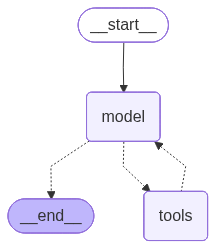

In [9]:
from IPython.display import Image, display

try:
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [10]:
while True:
    user_input = input("User: ")
    if user_input.lower() in ["q", "exit", "quit"]:
        break

    response = agent.invoke(
        {"messages": [{"role": "user", "content": user_input}]},
        config={"configurable": {"user_id": "user_123", "thread_id": "1"}}
    )

    for msg in response["messages"]:
        msg.pretty_print()

================================ Human Message =================================

안녕! 나 요즘 다이어트 중이라, 주 3회씩 운동하고 있는데 힘드네 ㅠㅠ 얼른 5키로 정도 감량하고 싶어
================================== Ai Message ==================================
Tool Calls:
  save_user_info (call_RgG74KJD1sCXpZauqeckpVRi)
 Call ID: call_RgG74KJD1sCXpZauqeckpVRi
  Args:
    current_activities: ['다이어트']
    routines: ['주 3회 운동']
    goals: ['5kg 감량']
  search_user_memories (call_pfqzalZc15nUbnOlOW6iFGhU)
 Call ID: call_pfqzalZc15nUbnOlOW6iFGhU
  Args:
    query: 주 3회 운동
    category: routines
================================= Tool Message =================================
Name: save_user_info

사용자 메모리가 성공적으로 저장되었습니다: 1개의 current_activities, 1개의 goals, 1개의 routines가 추가되었습니다.
================================= Tool Message =================================
Name: search_user_memories

routines 카테고리에서 관련된 메모리를 찾을 수 없습니다.
================================== Ai Message ==================================

다이어트하고 주 3회 운동하는 게 쉽지 않은 일인데 열심

In [11]:
while True:
    user_input = input("User: ")
    if user_input.lower() in ["q", "exit", "quit"]:
        break

    response = agent.invoke(
        {"messages": [{"role": "user", "content": user_input}]},
        config={"configurable": {"user_id": "user_123", "thread_id": "2"}}
    )

    for msg in response["messages"]:
        msg.pretty_print()

================================ Human Message =================================

운동 하기 싫다
================================== Ai Message ==================================
Tool Calls:
  search_user_memories (call_BWyq225fSOcGkPELgrhpmOD6)
 Call ID: call_BWyq225fSOcGkPELgrhpmOD6
  Args:
    query: 운동
    category: routines
    limit: 5
  search_user_memories (call_lvnjMGA21hGcjLGLwUQ0jyyx)
 Call ID: call_lvnjMGA21hGcjLGLwUQ0jyyx
  Args:
    query: 운동
    category: goals
    limit: 5
================================= Tool Message =================================
Name: search_user_memories

routines 관련 메모리:
- 주 3회 운동 (저장일자: 2025-10-30T08:59:06.986758)

================================= Tool Message =================================
Name: search_user_memories

goals 관련 메모리:
- 5kg 감량 (저장일자: 2025-10-30T08:59:06.986758)

================================== Ai Message ==================================

운동하기 싫은 날도 있죠. 하지만 주 3회 운동을 하고 계시고, 5kg 감량 목표도 가지고 계신 만큼 조금씩 꾸준히 하는 것이 중요해요. 혹시 요즘 운동에 대한 동

In [ ]:
while True:
    user_input = input("User: ")
    if user_input.lower() in ["q", "exit", "quit"]:
        break

    response = agent.invoke(
        {"messages": [{"role": "user", "content": user_input}]},
        config={"configurable": {"user_id": "user_123", "thread_id": "3"}}
    )

    for msg in response["messages"]:
        msg.pretty_print()

================================ Human Message =================================

안녕! 나에 대해 아는 것 다 말해봐.
================================== Ai Message ==================================
Tool Calls:
  get_user_info (call_bemX9awrPwz67ZpfsTWvMXW6)
 Call ID: call_bemX9awrPwz67ZpfsTWvMXW6
  Args:
  search_user_memories (call_G4tKLT1EWIdQFUSlb2UdVtF4)
 Call ID: call_G4tKLT1EWIdQFUSlb2UdVtF4
  Args:
    query: current_activities
================================= Tool Message =================================
Name: get_user_info

{'user_name': 'mina', 'user_age': 25}
================================= Tool Message =================================
Name: search_user_memories

관련 메모리:
[current_activities] 다이어트 (저장일자: 2025-10-30T08:59:06.986758)
[concerns] 회사일 스트레스 (저장일자: 2025-10-30T09:00:07.003770)
[routines] 주 3회 운동 (저장일자: 2025-10-30T08:59:06.986758)
[preferences] 닭가슴살 좋아함 (저장일자: 2025-10-30T08:59:19.313584)
[goals] 5kg 감량 (저장일자: 2025-10-30T08:59:06.986758)

================================== Ai 

In [ ]:
# 안녕! 나 요즘 다이어트 중이라, 주 3회씩 운동하고 있는데 힘드네 ㅠㅠ 얼른 5키로 정도 감량하고 싶어
# 닭가슴살을 좋아하는데, 식단 추천해줄 수 있어?


# 운동 하기 싫다
# 고마워. 요즘 회사일 때문에 스트레스를 받았더니 아무 것도 하기 싫네.


# 나에 대해 아는 것 다 말해봐.